# Question 1

In [1]:
# ===============================================
# Task : Implementing an RNN for Text Generation
# ===============================================

import tensorflow as tf
import numpy as np

# ============================================
# 1. Load and Prepare the Text Dataset
# ============================================

# Download the Shakespeare Sonnets dataset from Project Gutenberg
path_to_file = tf.keras.utils.get_file(
    'sonnets.txt',
    'https://www.gutenberg.org/cache/epub/1041/pg1041.txt'
)

# Read the text file
with open(path_to_file, 'rb') as f:
    text = f.read().decode(encoding='utf-8')

# Remove Project Gutenberg header and footer information
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

start_idx = text.find(start_marker)
end_idx = text.find(end_marker)

if start_idx != -1 and end_idx != -1:
    text = text[text.find('\n', start_idx) + 1:end_idx]

# Display basic information about the dataset
print(f"Text length: {len(text)} characters")

# ============================================
# 2. Convert Characters to Integer IDs
# ============================================

# Create a vocabulary containing all unique characters
vocab = sorted(set(text))
vocab_size = len(vocab)

# Map each character to an integer ID
char2idx = {char: idx for idx, char in enumerate(vocab)}

# Map integer IDs back to characters for text generation
idx2char = np.array(vocab)

# Convert the entire text into a sequence of integer IDs
text_as_int = np.array([
    char2idx[char]
    for char in text
])


# ============================================
# 3. Create Training Sequences
# ============================================

# Each input sequence contains 100 characters
seq_length = 100

# Create a TensorFlow dataset from the integer sequence
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

# Create sequences of length 101
# The extra character is used as the target (next character)
sequences = char_dataset.batch(
    seq_length + 1,
    drop_remainder=True
)


# Split each sequence into input and target
# The model learns to predict the next character
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text


dataset = sequences.map(split_input_target)


# Create batches of 64 training examples
BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(
    BATCH_SIZE,
    drop_remainder=True
)


# ============================================
# 4. Build the LSTM Model
# ============================================

def build_model(
    vocab_size,
    embedding_dim,
    rnn_units,
    batch_size
):

    # Input shape:
    # (batch_size, sequence_length)
    inputs = tf.keras.Input(
        batch_shape=(batch_size, None),
        dtype=tf.int32
    )

    # Convert character IDs into dense vector representations
    x = tf.keras.layers.Embedding(
        vocab_size,
        embedding_dim
    )(inputs)

    # LSTM processes the character sequence and
    # returns an output for every time step
    x = tf.keras.layers.LSTM(
        rnn_units,
        return_sequences=True,
        stateful=True,
        recurrent_initializer='glorot_uniform'
    )(x)

    # Predict the next character.
    # Each time step produces one score (logit) for every character
    outputs = tf.keras.layers.Dense(vocab_size)(x)

    # Create the complete model
    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    return model


# Model hyperparameters
embedding_dim = 256
rnn_units = 1024

# Build the training model
model = build_model(
    vocab_size,
    embedding_dim,
    rnn_units,
    BATCH_SIZE
)


# ============================================
# 5. Compile and Train the Model
# ============================================

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    )
)

# Display the model architecture
model.summary()

# Train the LSTM model
EPOCHS = 10

history = model.fit(
    dataset,
    epochs=EPOCHS
)


# ============================================
# 6. Build a Model for Text Generation
# ============================================

def build_model_for_inference(
    vocab_size,
    embedding_dim,
    rnn_units
):

    # During text generation, we use batch size = 1
    inputs = tf.keras.Input(
        batch_shape=(1, None),
        dtype=tf.int32
    )

    # Embedding layer
    x = tf.keras.layers.Embedding(
        vocab_size,
        embedding_dim
    )(inputs)

    # LSTM layer
    x = tf.keras.layers.LSTM(
        rnn_units,
        return_sequences=True,
        stateful=True,
        recurrent_initializer='glorot_uniform'
    )(x)

    # Output layer for character prediction
    outputs = tf.keras.layers.Dense(vocab_size)(x)

    # Create the inference model
    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    return model


# Build the inference model
inference_model = build_model_for_inference(
    vocab_size,
    embedding_dim,
    rnn_units
)

# Copy the trained weights from the training model to the inference model
inference_model.set_weights(model.get_weights())


# ============================================
# 7. Reset LSTM States
# ============================================

def reset_model_states(model):

    # Reset the internal states of stateful RNN layers
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()


# ============================================
# 8. Generate Text
# ============================================

def generate_text(
    model,
    start_string,
    num_generate=500,
    temperature=1.0
):

    # Reset the LSTM states before generating new text
    reset_model_states(model)

    # Convert the starting string into integer IDs
    input_eval = [
        char2idx[char]
        for char in start_string
    ]

    # Add the batch dimension
    input_eval = tf.expand_dims(
        input_eval,
        0
    )

    text_generated = []

    # Generate one character at a time
    for _ in range(num_generate):

        # Get the model's predictions
        predictions = model(input_eval)

        # Remove the batch dimension
        predictions = tf.squeeze(predictions, 0)

        # Apply temperature scaling
        # Lower temperature -> less random
        # Higher temperature -> more random
        predictions = predictions / temperature

        # Randomly sample one character based on the predicted logits
        predicted_id = tf.random.categorical(
            predictions,
            num_samples=1
        )[-1, 0].numpy()

        # Use the predicted character as the next input
        input_eval = tf.expand_dims(
            [predicted_id],
            0
        )

        # Convert the predicted ID back to a character
        text_generated.append(
            idx2char[predicted_id]
        )

    # Return the original prompt plus the generated text
    return start_string + ''.join(text_generated)


# ============================================
# 9. Generate New Text
# ============================================

print("\nGenerated Text:")
print(
    generate_text(
        inference_model,
        start_string="Hello"
    )
)

Text length: 98843 characters


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (64, None)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (64, None, 256)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, None, 65)         │        66,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,330,241 (20.33 MB)

 Trainable params: 5,330,241 (20.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


C:\Windows\System32\tensorflow_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - loss: 3.4643 
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - loss: 2.9642
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - loss: 2.5632
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - loss: 2.3354
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - loss: 2.1881
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - loss: 2.0875 
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - loss: 2.0044
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - loss: 1.9411
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - loss: 1.8797
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - loss: 1.8259

Generated Text:
Hellorn my ortraingen to so.
I arterems to blower ig illuety
Loum taks you bendy amfure agains and least on see
S I woongrests that to hom trye woos gatt hed live,
Rot betile als a natear ever-staon;,
O cath to cranse why woth mind yould
HoJ athoundore soum make that hime?

CXXIXII

 For trou the anvert enom my love,
For pantt my sime; tho

**Temperature scaling** controls the randomness of text generation by adjusting the model's output logits before sampling. A lower temperature (less than 1.0) makes the model more deterministic because it increases the preference for high-probability characters. A higher temperature (greater than 1.0) makes the generated text more random and diverse by allowing lower-probability characters to be selected more often. When the temperature is 1.0, the original output distribution is maintained. Therefore, temperature allows us to control the balance between predictable and diverse text generation.

# Question 2

Training samples: 25000
Testing samples: 25000
Training shape: (25000, 200)
Testing shape: (25000, 200)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 107s 323ms/step - accuracy: 0.5204 - loss: 0.6915 - val_accuracy: 0.5210 - val_loss: 0.6910
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 305ms/step - accuracy: 0.5717 - loss: 0.6716 - val_accuracy: 0.5626 - val_loss: 0.6696
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 318ms/step - accuracy: 0.5966 - loss: 0.6442 - val_accuracy: 0.5420 - val_loss: 0.6938
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 340ms/step - accuracy: 0.7220 - loss: 0.5401 - val_accuracy: 0.7800 - val_loss: 0.5067
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 340ms/step - accuracy: 0.8640 - loss: 0.3404 - val_accuracy: 0.8472 - val_loss: 0.3789

Test Accuracy: 0.8328400254249573

Confusion Matrix:
[[10373  2127]
 [ 2052 10448]]


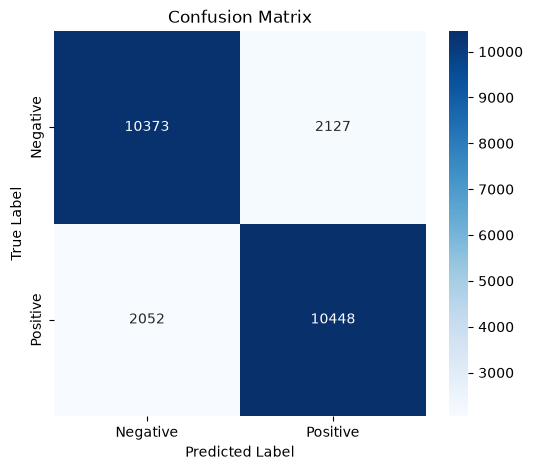


Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.83      0.83     12500
    Positive       0.83      0.84      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



In [4]:
# ===========================================
# Task: Sentiment Classification Using RNN
# ===========================================

import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================
# 1. Load IMDB Dataset
# ============================================

vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))


# ============================================
# 2. Tokenization and Padding
# ============================================

# Maximum length of each review
max_length = 200

# Pad or truncate training sequences
x_train = pad_sequences(
    x_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Pad or truncate testing sequences
x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)


# ============================================
# 3. Build LSTM Model
# ============================================

model = Sequential([
    
    # Input: sequence of integer word IDs
    tf.keras.Input(shape=(max_length,)),
    
    # Convert word IDs into dense vectors
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    # LSTM processes the sequence
    LSTM(128),

    # Binary classification:
    # 0 = Negative
    # 1 = Positive
    Dense(1, activation='sigmoid')
])


# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# ============================================
# 4. Train the Model
# ============================================

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


# ============================================
# 5. Evaluate the Model
# ============================================

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTest Accuracy:", test_accuracy)


# ============================================
# 6. Generate Predictions
# ============================================

# Predict the probability of Positive sentiment
y_prob = model.predict(
    x_test,
    verbose=0
)

# Convert probabilities into class labels
# Probability >= 0.5 -> Positive (1)
# Probability < 0.5 -> Negative (0)
y_pred = (y_prob >= 0.5).astype(int).flatten()


# ============================================
# 7. Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# Display confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# ============================================
# 8. Classification Report
# ============================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Negative', 'Positive']
    )
)


**Precision-Recall Tradeoff:** Precision measures how many reviews predicted as a particular sentiment are actually that sentiment, while recall measures how many reviews that actually belong to that sentiment are correctly identified. Increasing recall may result in more false positive predictions, which can reduce precision. On the other hand, increasing precision may cause the model to miss some relevant positive or negative reviews, reducing recall. Therefore, both precision and recall are important in sentiment classification rather than relying only on accuracy. The appropriate balance depends on the relative importance of false positive and false negative errors. F1-score combines precision and recall and provides a balanced measure of the two.

# Question 3

In [5]:
# ==================================================================
# Task 1: Implement Convolution with Different Stride and Padding 
# ==================================================================

import numpy as np
import tensorflow as tf

# 1. Define the 5x5 input matrix
input_matrix = np.array([
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
], dtype=np.float32)


# 2. Define the 3x3 kernel
kernel = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
], dtype=np.float32)


# Convert input matrix to TensorFlow format
# Shape: (batch, height, width, channels)
input_tensor = tf.constant(
    input_matrix.reshape(1, 5, 5, 1)
)

# Convert kernel to TensorFlow format
# Shape: (height, width, input_channels, output_channels)
kernel_tensor = tf.constant(
    kernel.reshape(3, 3, 1, 1)
)


# 3. Stride = 1, Padding = VALID
# strides: [batch step, height step, width step, channel step]
output_1 = tf.nn.conv2d(
    input_tensor,
    kernel_tensor,
    strides=[1, 1, 1, 1],
    padding='VALID'
)


# 4. Stride = 1, Padding = SAME
output_2 = tf.nn.conv2d(
    input_tensor,
    kernel_tensor,
    strides=[1, 1, 1, 1],
    padding='SAME'
)


# 5. Stride = 2, Padding = VALID
output_3 = tf.nn.conv2d(
    input_tensor,
    kernel_tensor,
    strides=[1, 2, 2, 1],
    padding='VALID'
)


# 6. Stride = 2, Padding = SAME
output_4 = tf.nn.conv2d(
    input_tensor,
    kernel_tensor,
    strides=[1, 2, 2, 1],
    padding='SAME'
)


# 7. Print the output feature maps
print("Stride = 1, Padding = VALID")
print(output_1.numpy().squeeze())


print("\nStride = 1, Padding = SAME:")
print(output_2.numpy().squeeze())


print("\nStride = 2, Padding = VALID:")
print(output_3.numpy().squeeze())


print("\nStride = 2, Padding = SAME:")
print(output_4.numpy().squeeze())

Stride = 1, Padding = VALID
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Stride = 1, Padding = SAME:
[[  4.   3.   2.   1.  -6.]
 [ -5.   0.   0.   0. -11.]
 [-10.   0.   0.   0. -16.]
 [-15.   0.   0.   0. -21.]
 [-46. -27. -28. -29. -56.]]

Stride = 2, Padding = VALID:
[[0. 0.]
 [0. 0.]]

Stride = 2, Padding = SAME:
[[  4.   2.  -6.]
 [-10.   0. -16.]
 [-46. -28. -56.]]


# Question 4--Task 1

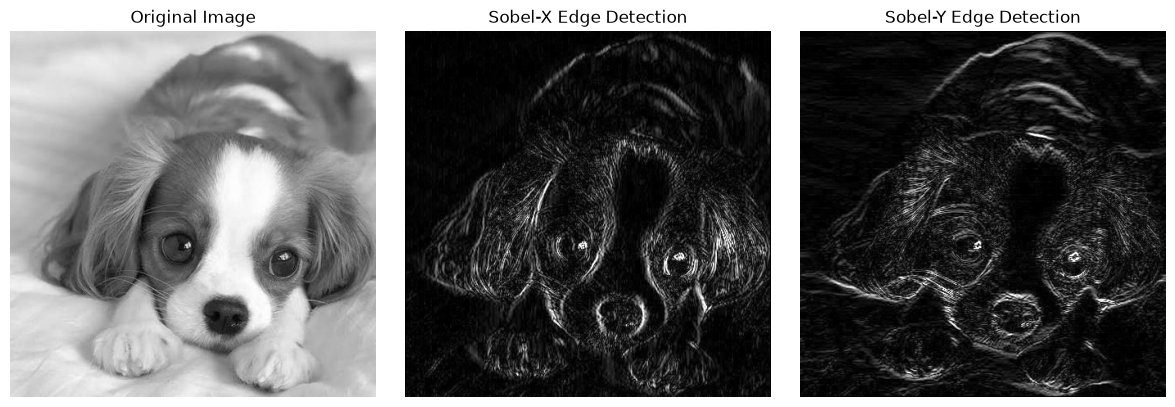

In [6]:
# ====================================================
# Task 1: Implement Edge Detection Using Convolution 
# ====================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
image = cv2.imread(r"C:\Users\ruyi4\Desktop\dog.jpg", cv2.IMREAD_GRAYSCALE)

# Sobel filters
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=np.float32)

# Apply filters
edge_x = cv2.filter2D(image, cv2.CV_32F, sobel_x)
edge_y = cv2.filter2D(image, cv2.CV_32F, sobel_y)

# Convert for display
edge_x = cv2.convertScaleAbs(edge_x)
edge_y = cv2.convertScaleAbs(edge_y)

# Display
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edge_x, cmap="gray")
plt.title("Sobel-X Edge Detection")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edge_y, cmap="gray")
plt.title("Sobel-Y Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

# Question 4--Task 2

In [7]:
# ====================================================
# Task 2: Implement Max Pooling and Average Pooling
# ====================================================

import numpy as np
from tensorflow.keras.layers import MaxPooling2D, AveragePooling2D

# Create a random 4x4 matrix
np.random.seed(42)

matrix = np.random.randint(1, 10, size=(4, 4))

print("Original Matrix:")
print(matrix)

# Convert to float32 and reshape
input_data = matrix.astype(np.float32).reshape(1, 4, 4, 1)

# 2x2 Max Pooling
max_pool = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding="valid"
)

# 2x2 Average Pooling
avg_pool = AveragePooling2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding="valid"
)

# Apply pooling
max_result = max_pool(input_data).numpy().squeeze()
avg_result = avg_pool(input_data).numpy().squeeze()

# Print results
print("\nMax Pooled Matrix:")
print(max_result)

print("\nAverage Pooled Matrix:")
print(avg_result)

Original Matrix:
[[7 4 8 5]
 [7 3 7 8]
 [5 4 8 8]
 [3 6 5 2]]

Max Pooled Matrix:
[[7. 8.]
 [6. 8.]]

Average Pooled Matrix:
[[5.25 7.  ]
 [4.5  5.75]]


# Question 5--Task 1

In [8]:
# ============================================
# Task 1: Implement AlexNet Architecture
# ============================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    
    # Layer 1: Conv2D, 55×55×96
    Conv2D(
        filters=96,
        kernel_size=(11, 11),
        strides=4,
        activation="relu",
        input_shape=(227, 227, 3)
    ),
    
    # Layer 2: MaxPooling, 27×27×96
    MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    ),
    
    # Layer 3: Conv2D, 23×23×256
    Conv2D(
        filters=256,
        kernel_size=(5, 5),
        activation="relu"
    ),
    
    # Layer 4: MaxPooling, 11×11×256
    MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    ),
    
    # Layer 5: Conv2D, 9×9×384
    Conv2D(
        filters=384,
        kernel_size=(3, 3),
        activation="relu"
    ),
    
    # Layer 6: Conv2D, 7×7×384
    Conv2D(
        filters=384,
        kernel_size=(3, 3),
        activation="relu"
    ),
    
    # Layer 7: Conv2D, 5×5×256
    Conv2D(
        filters=256,
        kernel_size=(3, 3),
        activation="relu"
    ),
    
    # Layer 8: MaxPooling, 2×2×256
    MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    ),
    
    # Layer 9: Flatten, 1024
    Flatten(),
    
    # Layer 10: Fully Connected (Dense)
    Dense(
        4096,
        activation="relu"
    ),
    
    # Layer 11: Dropout
    Dropout(0.5),
    
    # Layer 12: Fully Connected (Dense)
    Dense(
        4096,
        activation="relu"
    ),
    
    # Layer 13: Dropout
    Dropout(0.5),
    
    # Layer 14: Output
    Dense(
        10,
        activation="softmax"
    )
])

# Print model summary
model.summary()

C:\Windows\System32\tensorflow_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 23, 23, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,767,882 (94.48 MB)

 Trainable params: 24,767,882 (94.48 MB)

 Non-trainable params: 0 (0.00 B)

# Question 5--Task 2

In [9]:
# ============================================
# Task 2: Implement a Residual Block and ResNet
# ============================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Add,
    ReLU,
    Flatten,
    Dense
)

# 1. Define Residual Block
def residual_block(input_tensor, filters=64):

    # First Conv2D
    x = Conv2D(
        filters=filters,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )(input_tensor)

    # Second Conv2D
    x = Conv2D(
        filters=filters,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )(x)

    # Skip connection: add input to convolution output
    x = Add()([input_tensor, x])

    # Activation after addition
    x = ReLU()(x)

    return x

# 2. Define input
inputs = Input(shape=(224, 224, 3))

# 3. Initial Conv2D layer
x = Conv2D(
    filters=64,
    kernel_size=(7, 7),
    strides=2,
    padding="same",
    activation="relu"
)(inputs)

# 4. Apply two Residual Blocks
x = residual_block(x, filters=64)
x = residual_block(x, filters=64)

# 5. Flatten layer
x = Flatten()(x)

# 6. Dense layer
x = Dense(
    128,
    activation="relu"
)(x)

# 7. Output layer
outputs = Dense(
    10,
    activation="softmax"
)(x)

# 8. Create ResNet-like model
resnet_model = Model(
    inputs=inputs,
    outputs=outputs
)

# 9. Print model summary
resnet_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 112, 112,  │      9,472 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ conv2d_5[0][0],   │
│                     │ 64)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 112, 112,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 112, 112,  │          0 │ re_lu[0][0],      │
│                     │ 64)               │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ add_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 802816)    │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │ 102,760,5… │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10)        │      1,290 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 102,919,050 (392.61 MB)

 Trainable params: 102,919,050 (392.61 MB)

 Non-trainable params: 0 (0.00 B)